In [2]:
import numpy as np
import healpy as hp
from matplotlib import pyplot as plt

import sys
sys.path.append('../')

from scripts.compute_decoupled_cl import compute_decoupled_cl
from scripts.compute_weights import compute_weights
from scripts.apply_HILC import apply_HILC
from scripts.simulate_planck_maps import simulate_planck_maps
from scripts.cosine_smoothed_mask import cosine_smoothed_mask


In [3]:
def calculate_stats(cls: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Calculate the mean, error, and bias of the input power spectra.
    
    Args:
        cls (np.ndarray): Input power spectra with shape (nsims, lmax, ...) or (nsims, lmax).
    
    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]:
            - mean (np.ndarray): The mean of the input power spectra.
            - error (np.ndarray): The error of the input power spectra.
            - bias (np.ndarray): The bias of the input power spectra.
    """
    mean = np.mean(cls, axis=0)
    std = np.std(cls, axis=0)
    cmb_th =np.loadtxt("https://portal.nersc.gov/project/cmb/pysm-data/pysm_2/camb_lenspotentialCls.dat",skiprows=0, max_rows=382 ,usecols=(1))

    # Ensure mean and std are at least 2D for consistent indexing

    if mean.ndim == 1:
        error = (std / np.sqrt(nsims))
        bias = (mean-cmb_th ) / cmb_th  #not multiplying with norm(fsky)
    else:
        error = (std[2:, 0, 0] / np.sqrt(nsims))
        bias = ( mean[2:, 0, 0] -cmb_th ) / cmb_th
    
    return mean, error, bias

In [4]:
nside=128
npix=hp.nside2npix(nside)
lmax=3*nside -1    
freqs = np.array([28.4,  44.1,  70.4,  100.0,  143.0,  217.0,  353.0])
n_freqs=len(freqs)
ells = np.arange(lmax + 1)
norm = (ells * (ells+ 1)) / (2 * np.pi)
nsims=10

In [5]:
mask2=cosine_smoothed_mask(nside)
mask2= (mask2*(-1))+1

In [6]:
*_, cmb = simulate_planck_maps(nside, freqs)#PySM generated
hilc= apply_HILC(cmb)
dec_cmb=compute_decoupled_cl(cmb, mask2, False, nside,lmax, n_freqs)
#hilc_cmb == dec_cmb
input_cmb =np.loadtxt("https://portal.nersc.gov/project/cmb/pysm-data/pysm_2/camb_lenspotentialCls.dat",skiprows=0, max_rows=382 ,usecols=(1))
# mapcmb_th= hp.synfast(input_cmb, nside)
# dec_smooth_cmb=compute_decoupled_cl_2(mapcmb_th, mask2, nside,lmax, n_freqs)

hilc_cmb= compute_decoupled_cl(hilc,mask2, True, nside, lmax, n_freqs)


/tmp/ipykernel_113665/3548700904.py:5: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=382`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  input_cmb =np.loadtxt("https://portal.nersc.gov/project/cmb/pysm-data/pysm_2/camb_lenspotentialCls.dat",skiprows=0, max_rows=382 ,usecols=(1))


Comparing the PySM generated input cmb after decoupling to the HILC computed without any foregrounds or noise. Should gave the same result as the input decoupled CMB. However PySM CMB maps have a bias at high l

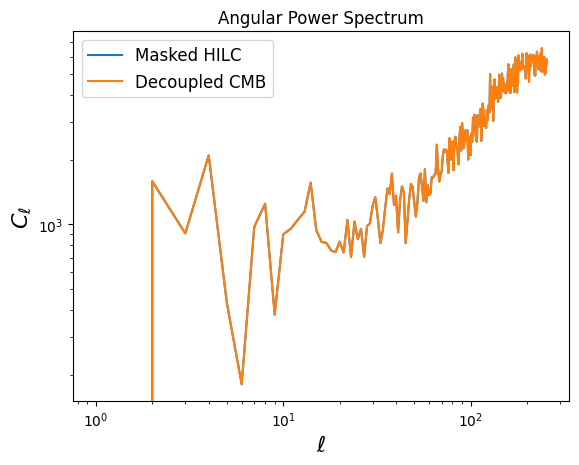

In [8]:
plt.plot(ells[:256], norm[:256]*hilc_cmb[:256,0,0], label='Masked HILC')
plt.plot(ells[:256], norm[:256]*dec_cmb[:256,0,0], label='Decoupled CMB')
# plt.plot(ells[2:], input_cmb, label='Theoretical CMB')
# plt.plot(ells[2:], dec_smooth_cmb[2:], label='theoretical decoupled CMB')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.xscale("log")
plt.yscale("log")
# plt.ylim(1e-3,1e4)
plt.legend(fontsize=12)
plt.title("Angular Power Spectrum")
plt.show()

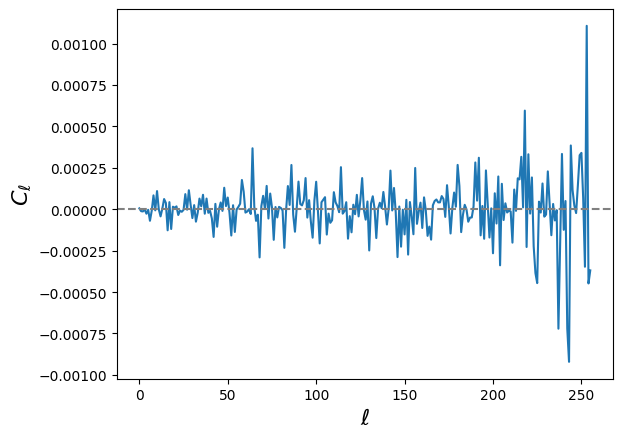

In [11]:
bias= (hilc_cmb-dec_cmb)/dec_cmb
# bias2= (dec_smooth_cmb[2:]-hilc_cmb[2:,0,0])/dec_smooth_cmb[2:]
plt.plot(ells[:256], bias[:256,0,0], label='Input CMB')
# plt.plot(ells[2:], bias2, label='Input CMB')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
# plt.xscale("log")
plt.axhline(0, linestyle="--", color="gray")
plt.show()

In [32]:
_,weights=compute_weights(7, lmax, dec_cmb)

In [37]:
for ell in range(lmax+1):
    sum_w = np.sum(weights[:, ell])  # Assuming weights[ell, i] is your weight array
    if not np.isclose(sum_w, 1.0):
        print(f"Warning: Weights at ℓ = {ell} sum to {sum_w:.6f}, not 1!")
    else:
        print("All ok")

All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok
All ok

For multiple realisations of the CMB map

In [72]:
cmb_pysm=np.load ("/home/iloveorcas/Internship_Rome/results/cls_maps.npy")
cmb_pysm=np.mean(cmb_pysm, axis=0)
print(cmb_pysm.shape)

(7, 196608)


In [70]:
hilc_pysm_map =np.load("/home/iloveorcas/Internship_Rome/results/cls_sims_cmb.npy")
hilc_pysm_map=np.mean(hilc_pysm_map,axis=0)
print(hilc_pysm_map.shape)

(384, 7, 7)


In [73]:

cmb_pysm_dec= compute_decoupled_cl(cmb_pysm, mask2, False, nside,lmax, n_freqs)

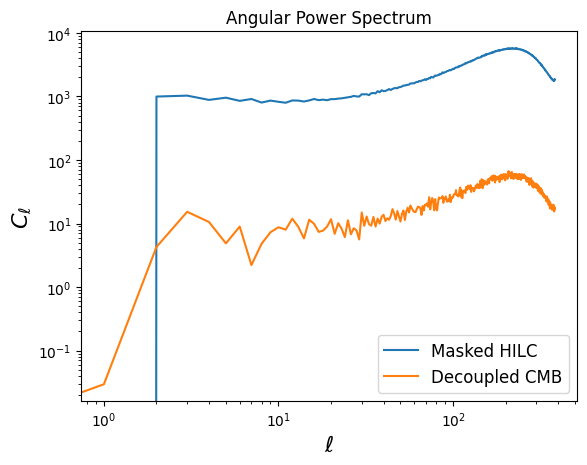

In [78]:
plt.plot(ells, norm*hilc_pysm_map[:,0,0], label='Masked HILC')
plt.plot(ells, norm*cmb_pysm_dec[:,0,0], label='Decoupled CMB')
# plt.plot(ells[2:], input_cmb, label='Theoretical CMB')
# plt.plot(ells[2:], dec_smooth_cmb[2:], label='theoretical decoupled CMB')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.xscale("log")
plt.yscale("log")
# plt.ylim(1e-3,1e4)
plt.legend(fontsize=12)
plt.title("Angular Power Spectrum")
plt.show()

Do the same for self generated decoupled mean CMB maps and input them into HILC. They should also give the same result!

In [38]:
cl_self_gen = np.load("/home/iloveorcas/Internship_Rome/results/cl_raw.npy")

In [39]:
cl_self_mean, *_= calculate_stats(cl_self_gen)

/tmp/ipykernel_88167/2096218221.py:16: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=382`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  cmb_th =np.loadtxt("https://portal.nersc.gov/project/cmb/pysm-data/pysm_2/camb_lenspotentialCls.dat",skiprows=0, max_rows=382 ,usecols=(1))


convert to maps to be input to hilc algorithm

In [43]:
cl_self_gen_map= np.load("/home/iloveorcas/Internship_Rome/results/cmb_raw.npy")
cl_self_gen_map=np.mean(cl_self_gen_map, axis=0)
print(cl_self_gen_map.shape)

(7, 196608)


In [55]:
cl_self_dec = compute_decoupled_cl(cl_self_gen_map, mask2, False, nside, lmax, n_freqs)
hilc2_map= apply_HILC(cl_self_gen_map)
hilc2_cl= compute_decoupled_cl(hilc2_map,mask2, True, nside, lmax, n_freqs)

In [56]:
np.allclose(hilc2_cl,cl_self_dec)

False

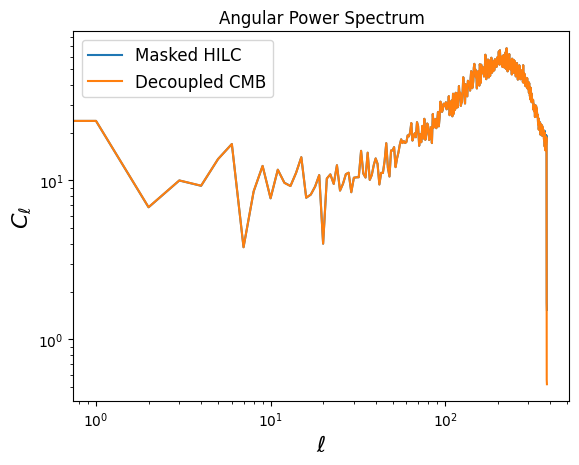

In [57]:
plt.plot(ells, hilc2_cl[:,0,0], label='Masked HILC')
plt.plot(ells, cl_self_dec[:,0,0], label='Decoupled CMB')
# plt.plot(ells[2:], input_cmb, label='Theoretical CMB')
# plt.plot(ells[2:], dec_smooth_cmb[2:], label='theoretical decoupled CMB')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.xscale("log")
plt.yscale("log")
# plt.ylim(1e-3,1e4)
plt.legend(fontsize=12)
plt.title("Angular Power Spectrum")
plt.show()

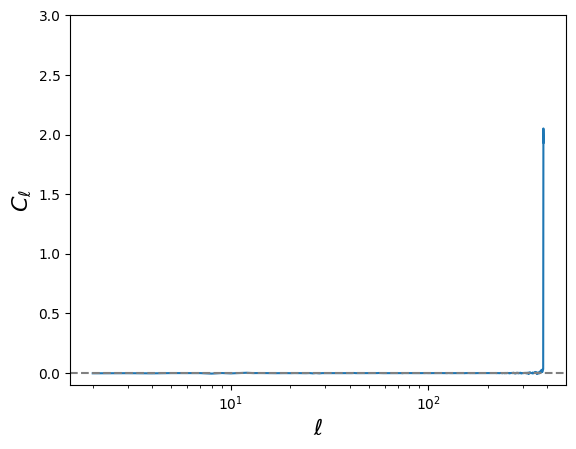

In [61]:
cl_self_bias=(hilc2_cl - cl_self_dec)/cl_self_dec
plt.plot(ells[2:],cl_self_bias[2:,0,0] , label='Input CMB') #compared with dec cmb cl
plt.plot
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.xscale("log")
plt.ylim(-0.1,3)
plt.axhline(0, linestyle="--", color="gray")
plt.show()